In [1]:
!pip install yfinance newsapi-python stockstats langdetect

In [3]:
import yfinance as yf

print('This only deals with stocks listed on NSE & NASDAQ \n')
stock=input('enter a valid stock name : ').strip()


def convert_stock_NS(stock_name):
    NSE_STOCK=f'{stock_name}.NS'
    return NSE_STOCK

ans=input('Is your stock listed on NSE (y/n) : ').strip().lower()
if ans=='y':
    stock=convert_stock_NS(stock)
    stock_data=yf.download(stock,period="5y")
else :
    stock_data=yf.download(stock,period="5y")

This only deals with stocks listed on NSE & NASDAQ 

enter a valid stock name : AAPL
Is your stock listed on NSE (y/n) : n


/tmp/ipykernel_4106/1111721205.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data=yf.download(stock,period="5y")
[*********************100%***********************]  1 of 1 completed


In [4]:
stock_ticker = yf.Ticker(stock)
info = stock_ticker.info
stock_name=info.get('shortName', 'N/A')

print(f'\n***************{stock_name}***************\n')


stock_data


***************Apple Inc.***************



Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-04-15,131.002411,131.489409,130.164774,130.340101,89347100
2021-04-16,130.671265,131.167997,129.814144,130.807623,84922400
2021-04-19,131.333542,131.947164,129.872549,130.038126,94264200
2021-04-20,129.648560,132.005627,128.382362,131.508895,94812300
2021-04-21,130.028412,130.271911,127.885625,128.918057,68847100
...,...,...,...,...,...
2026-04-08,258.899994,259.750000,256.529999,258.450012,41032800
2026-04-09,260.489990,261.119995,256.070007,259.000000,28121600


In [5]:
import yfinance as yf
import pandas as pd
pd.set_option('display.max_columns', None)

recent_data=yf.download(stock,period="3mo", interval='60m')
print(f'\n***************{stock_name}***************\n')
recent_data

/tmp/ipykernel_4106/1683267859.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  recent_data=yf.download(stock,period="3mo", interval='60m')
[*********************100%***********************]  1 of 1 completed


***************Apple Inc.***************



Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2026-01-15 14:30:00+00:00,260.100098,261.029999,259.619995,260.649994,5046140
2026-01-15 15:30:00+00:00,260.494995,260.785095,259.190002,260.140015,2795244
2026-01-15 16:30:00+00:00,259.329987,260.630005,259.299988,260.500000,2122658
2026-01-15 17:30:00+00:00,259.529999,259.565002,258.000000,259.339996,2472715
2026-01-15 18:30:00+00:00,258.320007,259.750000,258.260010,259.549988,2003848
...,...,...,...,...,...
2026-04-14 15:30:00+00:00,257.700012,258.390015,257.190094,258.049988,4016733
2026-04-14 16:30:00+00:00,258.660004,259.765106,257.619995,257.690002,4098111


In [6]:
stock_data.columns = stock_data.columns.get_level_values(0)
recent_data.columns = recent_data.columns.get_level_values(0)

In [7]:
stock_data.columns.unique()

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

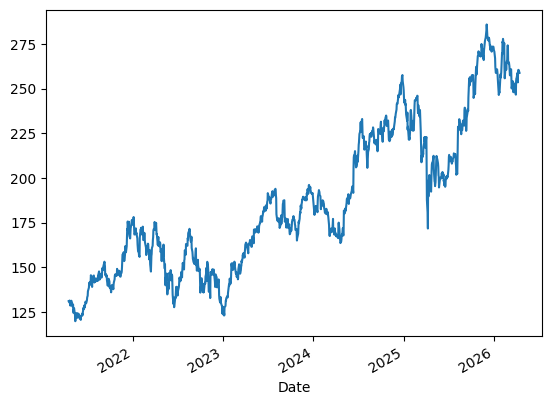

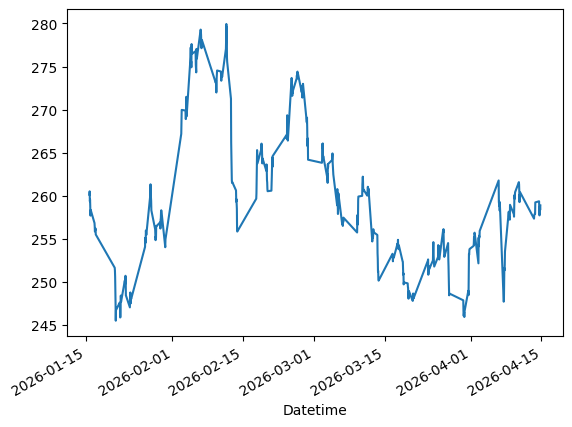

Price,close,open,high,low,volume
Date,,,,,
2021-04-15,131.002411,130.340101,131.489409,130.164774,89347100
2021-04-16,130.671265,130.807623,131.167997,129.814144,84922400
2021-04-19,131.333542,130.038126,131.947164,129.872549,94264200
2021-04-20,129.648560,131.508895,132.005627,128.382362,94812300
2021-04-21,130.028412,128.918057,130.271911,127.885625,68847100
...,...,...,...,...,...
2026-04-08,258.899994,258.450012,259.750000,256.529999,41032800
2026-04-09,260.489990,259.000000,261.119995,256.070007,28121600
2026-04-10,260.480011,259.980011,262.190002,259.019989,31291500


In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

stock_data['Close'].plot()
plt.show()

recent_data['Close'].plot()
plt.show()
pd.set_option('display.max_columns', None)

from stockstats import wrap
wrapped_data = wrap(stock_data)
wrapped_data.init_all()
#print(wrapped_data)
historical_data = wrapped_data[['close','open', 'high', 'low', 'volume']]
historical_data

In [9]:
from newsapi import NewsApiClient

In [10]:
api = NewsApiClient(api_key='1727fdcffd8b4c5e936a02fa17ebb381')

In [11]:
data = api.get_everything(q=f'{stock_name}')
articles = data['articles']

# for article in articles:
#     print(article['title'])  # or article['description'], etc.

In [12]:
from langdetect import detect, DetectorFactory
english_articles = []
for article in data['articles']:
    try:
        lang = detect(article['title'] if article['title'] else article['description'])
        if lang == 'en':
            english_articles.append(article)
    except:
        continue
# english_articles

In [13]:
from datetime import datetime
articles = sorted(english_articles, key=lambda x: datetime.strptime(x['publishedAt'], "%Y-%m-%dT%H:%M:%SZ"), reverse=True)

headlines = [article['title'] for article in articles[:15]]
headlines

['Global Smartphone Market Update: Apple Maintains Lead Followed By Samsung',
 'Apple Inc. (AAPL): Israel Englander Trims Stake',
 'Baton Rouge woman arrested, accused of stealing money from elderly LaPlace couple',
 '2026 Swift Student Challenge: Three Apps Created by Young Developers',
 'Apple seeks internal data from Samsung in South Korea in ongoing antitrust case',
 'What are the odds of Apple surviving?',
 "Big Tech's hiring boom is over. 2 charts show where its workforce stands now.",
 '2026 Peabody Award Nominees Include ‘No Other Land,’ ‘The Perfect Neighbor,’ and More',
 "This $599 MacBook Could Be Apple's Smartest Move Yet",
 'Apple AirPods Pro 3 $329.98 Delivered @ Costco (Bonus $20 Costco Shop Card with Trade in)',
 "If You Invested In Apple Stock Instead Of Buying iPhones Each Year, Here's How Much You'd Have Today",
 '‘Full time bad decision factory’: 2 arrested after drugs found in Trinity County house',
 "ICYMI: the 7 biggest tech stories of the week, from Apple's 50th

In [14]:
# from transformers import pipeline

# sentiment_pipeline = pipeline("text-classification", model="mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis")

# full_text = " ".join(headlines)

# result = sentiment_pipeline(full_text[:512])

# print(f"Overall Sentiment for Combined Text: {result[0]['label']}")
# print(f"Confidence: {round(result[0]['score'] * 100, 2)}%")

In [16]:
# print("Article sample timestamp:", articles[0]['publishedAt'], type(articles[0]['publishedAt']), articles[0]['publishedAt'].tzinfo)
# print("Historical index sample:", historical_data.index[0], type(historical_data.index[0]), historical_data.index.tz)

In [17]:
import pandas as pd
from transformers import pipeline

for article in articles:
    article['publishedAt'] = pd.to_datetime(article['publishedAt']).tz_convert('UTC') \
        if pd.to_datetime(article['publishedAt']).tzinfo is not None \
        else pd.to_datetime(article['publishedAt'], utc=True)

if historical_data.index.tz is None:
    historical_data.index = historical_data.index.tz_localize("UTC")

sentiment_pipeline = pipeline("text-classification", model="mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
sentiments = []
confidences = []
news_counts = []
weighted_scores = []

label_map = {
    "POSITIVE": 1,
    "NEUTRAL": 0,
    "NEGATIVE": -1
}

for timestamp in historical_data.index:
    relevant_news = [
        article for article in articles
        if article['publishedAt'] <= timestamp
    ]

    news_counts.append(len(relevant_news))

    if relevant_news:
        full_text = " ".join([(a['title'] or '') + ' ' + (a['description'] or '') for a in relevant_news])
        full_text = full_text[:512]
        result = sentiment_pipeline(full_text)[0]

        label = result['label'].upper()
        confidence = round(result['score'], 2)

        sentiments.append(label)
        confidences.append(confidence)
        weighted_scores.append(label_map[label] * confidence)
    else:
        sentiments.append("NEUTRAL")
        confidences.append(None)
        weighted_scores.append(0.0)

# Add columns to DataFrame
historical_data['News_Sentiment'] = sentiments
historical_data['Sentiment_Confidence'] = confidences
historical_data['Num_Relevant_News'] = news_counts
historical_data['Weighted_Sentiment'] = weighted_scores

# Preview

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [19]:
import pandas as pd

print(historical_data[['close', 'News_Sentiment', 'Sentiment_Confidence', 'Num_Relevant_News', 'Weighted_Sentiment']])

Price                           close News_Sentiment  Sentiment_Confidence  \
Date                                                                         
2021-04-15 00:00:00+00:00  131.002411        NEUTRAL                   NaN   
2021-04-16 00:00:00+00:00  130.671265        NEUTRAL                   NaN   
2021-04-19 00:00:00+00:00  131.333542        NEUTRAL                   NaN   
2021-04-20 00:00:00+00:00  129.648560        NEUTRAL                   NaN   
2021-04-21 00:00:00+00:00  130.028412        NEUTRAL                   NaN   
...                               ...            ...                   ...   
2026-04-08 00:00:00+00:00  258.899994        NEUTRAL                  0.88   
2026-04-09 00:00:00+00:00  260.489990        NEUTRAL                  1.00   
2026-04-10 00:00:00+00:00  260.480011        NEUTRAL                  1.00   
2026-04-13 00:00:00+00:00  259.200012       POSITIVE                  1.00   
2026-04-14 00:00:00+00:00  258.829987       POSITIVE            

<Figure size 1200x600 with 0 Axes>

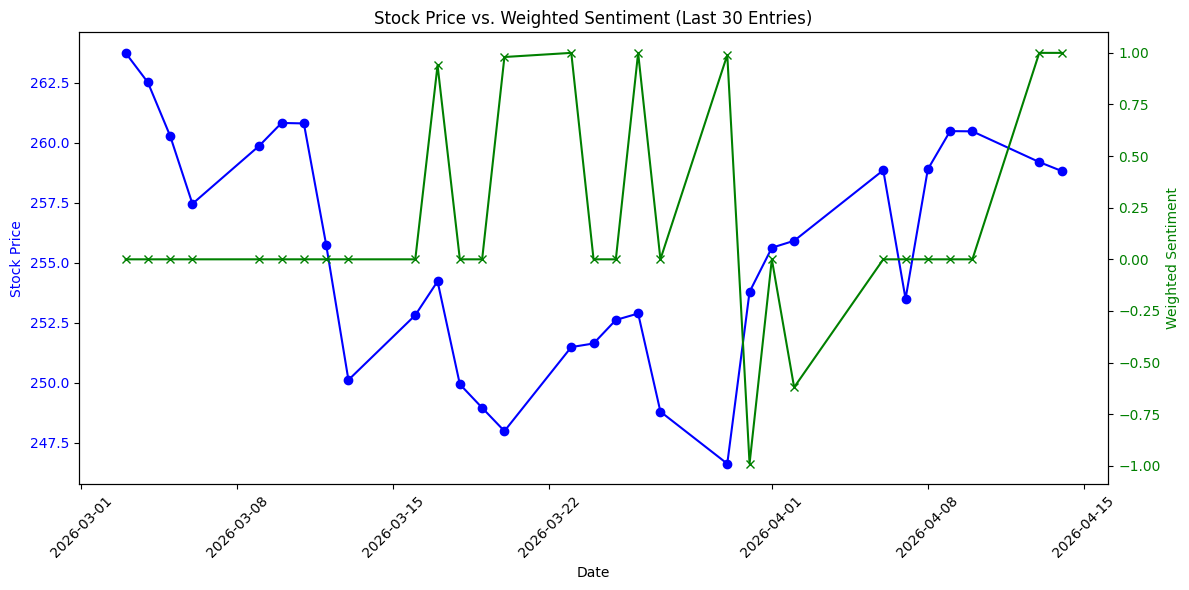

In [20]:
last_30 = historical_data.tail(30)

plt.figure(figsize=(12, 6))

# Create a twin axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot stock price on primary y-axis
ax1.plot(last_30.index, last_30['close'], label='Stock Price (Close)', color='blue', marker='o')
ax1.set_xlabel('Date')
ax1.set_ylabel('Stock Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.tick_params(axis='x', rotation=45)

# Create secondary y-axis for sentiment
ax2 = ax1.twinx()
ax2.plot(last_30.index, last_30['Weighted_Sentiment'], label='Weighted Sentiment', color='green', marker='x')
ax2.set_ylabel('Weighted Sentiment', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Title and layout
plt.title('Stock Price vs. Weighted Sentiment (Last 30 Entries)')
fig.tight_layout()
plt.show()

In [21]:
import numpy as np
import pandas as pd
import datetime as dt
from sklearn.preprocessing import MinMaxScaler

mid_prices = ((historical_data['high'] + historical_data['low']) / 2).interpolate().values
split_index = int(len(mid_prices) * 0.8)
train_raw = mid_prices[:split_index]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
original_train=train_scaled.copy()
window_size = 100
N = len(train_scaled)

std_avg_predictions = []
mse_errors = []
std_avg_dates = []

for i in range(window_size, N):
    prediction = np.mean(train_scaled[i - window_size:i])
    std_avg_predictions.append(prediction)

    mse_errors.append((prediction - train_scaled[i]) ** 2)

    if i < len(historical_data):
        date = historical_data.index[i]
    else:
        last_date = pd.to_datetime(historical_data.index[-1])
        date = last_date + dt.timedelta(days=i - len(historical_data) + 1)
    std_avg_dates.append(date)

predictions_actual = scaler.inverse_transform(np.array(std_avg_predictions).reshape(-1, 1)).flatten()
true_actual = scaler.inverse_transform(train_scaled[window_size:].reshape(-1, 1)).flatten()

mse_actual = 0.5 * np.mean((predictions_actual - true_actual) ** 2)
print(f"MSE in actual price scale: {mse_actual:.2f}")

MSE in actual price scale: 116.36


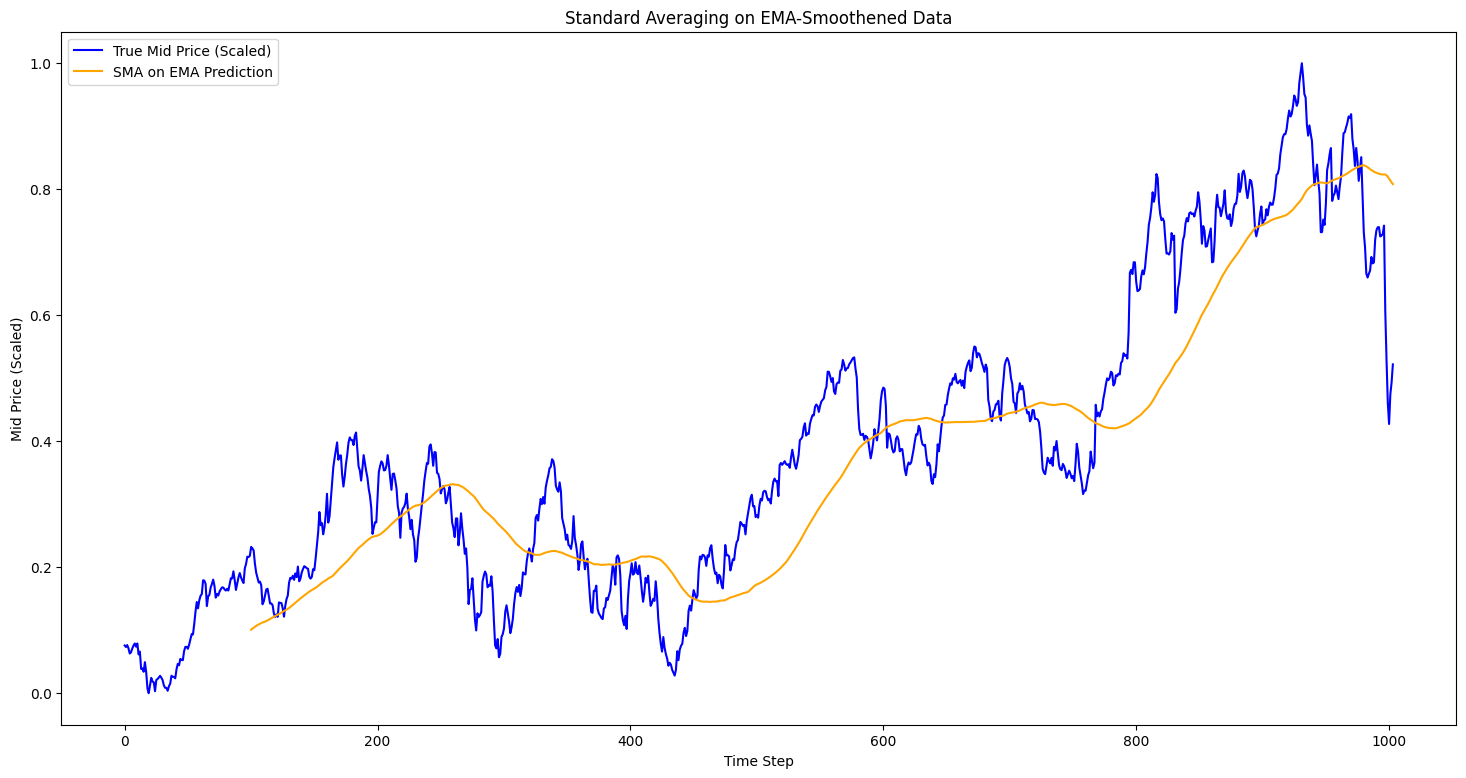

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 9))
plt.plot(original_train, label='True Mid Price (Scaled)', color='blue')
plt.plot(range(window_size, len(original_train)), std_avg_predictions, label='SMA on EMA Prediction', color='orange')
plt.xlabel('Time Step')
plt.ylabel('Mid Price (Scaled)')
plt.title('Standard Averaging on EMA-Smoothened Data')
plt.legend()
plt.show()

In [23]:
N = len(train_scaled)
decay = 0.5

run_avg_predictions = []
run_avg_dates = []
mse_errors = []

running_mean = train_scaled[0]
run_avg_predictions.append(running_mean)

for i in range(1, N):
    running_mean = running_mean * decay + (1.0 - decay) * train_scaled[i - 1]
    run_avg_predictions.append(running_mean)

    if i < len(historical_data):
        date = historical_data.index[i]
    else:
        last_date = pd.to_datetime(historical_data.index[-1])
        date = last_date + dt.timedelta(days=i - len(historical_data) + 1)
    run_avg_dates.append(date)

predictions_actual = scaler.inverse_transform(np.array(run_avg_predictions[1:]).reshape(-1, 1)).flatten()
true_actual = scaler.inverse_transform(train_scaled[1:].reshape(-1, 1)).flatten()

mse_actual = 0.5 * np.mean((predictions_actual - true_actual) ** 2)
print(f"MSE error for EMA averaging : {mse_actual:.2f}")

MSE error for EMA averaging : 5.35


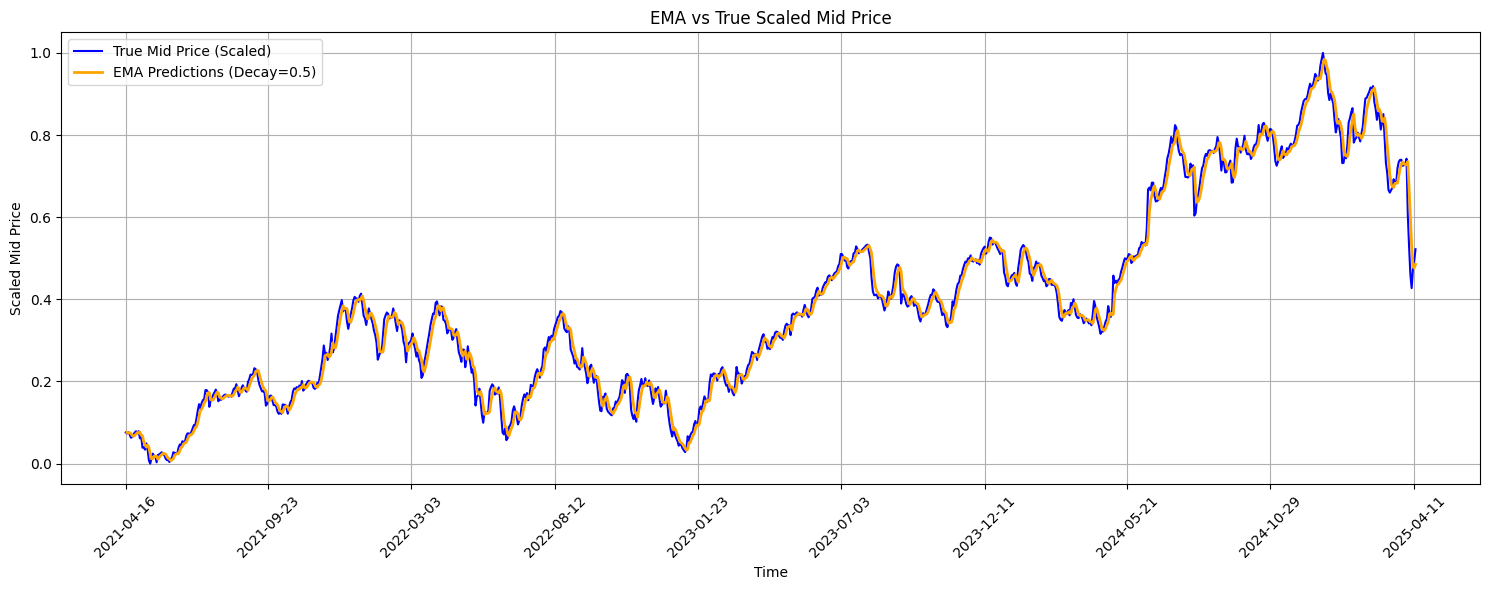

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(train_scaled, label='True Mid Price (Scaled)', color='blue', linewidth=1.5)

plt.plot(range(1, len(run_avg_predictions)), run_avg_predictions[1:],
         label='EMA Predictions (Decay=0.5)', color='orange', linewidth=2)

if len(run_avg_dates) == len(run_avg_predictions) - 1:
    plt.xticks(ticks=np.linspace(0, len(run_avg_dates)-1, 10, dtype=int),
               labels=[run_avg_dates[i].strftime('%Y-%m-%d') for i in np.linspace(0, len(run_avg_dates)-1, 10, dtype=int)],
               rotation=45)

plt.title('EMA vs True Scaled Mid Price')
plt.xlabel('Time')
plt.ylabel('Scaled Mid Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

In [27]:
features = historical_data[['open', 'high', 'low', 'volume','Weighted_Sentiment']].values
target = historical_data[['close']].values

train_size = int(len(features) * 0.8)
X_train_raw, X_test_raw = features[:train_size], features[train_size:]
y_train_raw, y_test_raw = target[:train_size], target[train_size:]

In [29]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

In [30]:
def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []
    for i in range(window_size, len(X)):
        X_seq.append(X[i - window_size:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

window_size = 60
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, window_size)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, window_size)
model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,985 (70.25 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(X_train_seq, y_train_seq, epochs=18, batch_size=32, validation_data=(X_test_seq, y_test_seq), verbose=1)

Epoch 1/18
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0173 - val_loss: 0.0118
Epoch 2/18
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021 - val_loss: 0.0046
Epoch 3/18
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0018 - val_loss: 0.0061
Epoch 4/18
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - val_loss: 0.0060
Epoch 5/18
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0017 - val_loss: 0.0046
Epoch 6/18
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0017 - val_loss: 0.0050
Epoch 7/18
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0016 - val_loss: 0.0034
Epoch 8/18
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0015 - val_loss: 0.0028
Epoch 9/18
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - val_loss: 0.0050
Epoch 10/18
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0015 - val_loss: 0.0024
Epoch 11/18
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0014 - val_loss: 0.0021
Epoch 12/18
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

In [32]:
predicted_scaled = model.predict(X_test_seq)
predicted = scaler_y.inverse_transform(predicted_scaled)
y_true = scaler_y.inverse_transform(y_test_seq)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


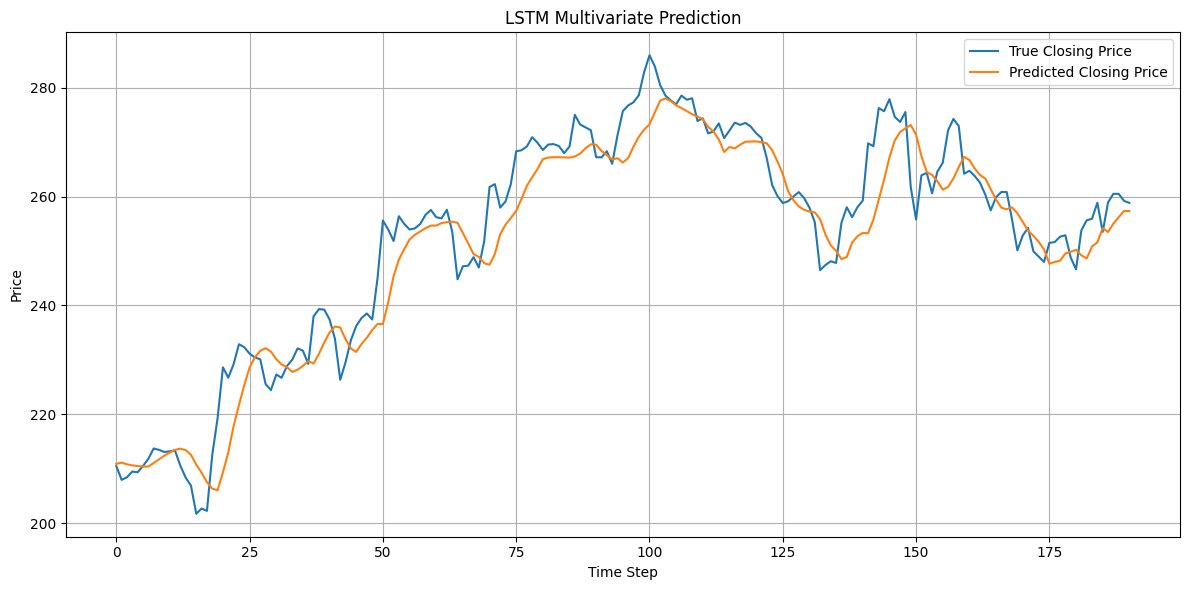

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(y_true, label='True Closing Price')
plt.plot(predicted, label='Predicted Closing Price')
plt.title('LSTM Multivariate Prediction')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_true, predicted)
print(f"MSE between y_true and predicted: {mse:.5f}")

MSE between y_true and predicted: 37.49367
